<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8016/blob/main/Session1_0_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn # Capas

# Optimizers
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Datos de imagenes: 2D
#           0       1 2 3
# x: [n_batch,in_chan,h,w]
# y = Conv2d(x)  ->   [n_batch,out_chan,h,w]
#
# Datos lineales (o otras cosas)
# x: [n_batch,n_chan]
# y = Linear(x)  ->   [n_batch,in_chan][in_chan,out_chan] = [n_batch,out_chan]

# Si insertamos una imagen RGB
# x: [n_batch,3,h,w]
# Aqui insertamos una imagen Gray
# x: [n_batch,1,h,w]

# flatten(x) = y [n_batch,1*h*w]

net = nn.Sequential(
    nn.flatten(1),
    nn.Linear(784, 256),    # 28*28 = 784
    nn.ReLU(inplace=True),
    nn.Linear(256, 10)
    # El CrossEntropy contiene el Softmax
)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self. fc1 = nn.Linear(28*28, 256)
        self. fc2 = nn.Linear(  256,  10)

        self.ReLU = nn.ReLU(inplace=True)

    def forward(self, x):
        x = x.flatten(1)
        x = self. fc1(x)
        x = self.ReLU(x)
        x = self. fc2(x)
        return x
net = MLP()

In [ ]:
transform = transforms.Compose([
    # PIL, numpy -> Tensor (uso de pytorch)
    transforms.ToTensor(),

    # Normalizacion por media y desviación
    transforms.Normalize((0.1307,), (0.3081,))  # Valores de 1 dimension (escala de grises)

    # Si trabajamos con RBG (por ejemplo ImageNet)
    # transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])
trainDataset = datasets.MNIST(root='./data', train=True , download=True, transform=transform)
testDataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.78MB/s]


In [ ]:
trainLoader = DataLoader(trainDataset, batch_size=64, shuffle= True)
testLoader  = DataLoader( testDataset, batch_size=64, shuffle=False)

In [ ]:
# Pasar la red a la GPU
net = net.to(device)

# Loss
criterion = nn.CrossEntropyLoss()   # Ya tiene softmax

# Optimizer
optimizer = optim.AdamW(net.parameters(), lr=0.001)

In [ ]:
n_epoch = 20
train_losses = []
test_losses = []

for epoch in range(n_epoch):
    # Training
    net.train() # Avisa a algunas capas (ej Dropout, BatchNorm) que estamos en entrenamiento
    total_train_loss = 0
    for images, labels in trainLoader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = net(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()     # Backpropagation
        optimizer.step()    # Avisar a AdamW que hemos realizado un paso de entrenamiento
                            # Recuerda: AdamW usa primer y segundo momento
                            #           - m_{t+1}=m_{t}+g_t
                            #           - v_{t+1}=v_{t}+g^2_t

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(trainLoader)
    train_losses.append(avg_train_loss)

    # Evaluation
    net.eval()
    total_test_loss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)

            outputs = net(images)
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(testLoader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1}/{n_epoch}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Epoch [1/20], Train Loss: 0.3461, Test Loss: 0.1895
Epoch [2/20], Train Loss: 0.1613, Test Loss: 0.1386
Epoch [3/20], Train Loss: 0.1168, Test Loss: 0.1075
Epoch [4/20], Train Loss: 0.0950, Test Loss: 0.0903
Epoch [5/20], Train Loss: 0.0811, Test Loss: 0.0888
Epoch [6/20], Train Loss: 0.0689, Test Loss: 0.0818
Epoch [7/20], Train Loss: 0.0645, Test Loss: 0.0918
Epoch [8/20], Train Loss: 0.0573, Test Loss: 0.0852
Epoch [9/20], Train Loss: 0.0508, Test Loss: 0.0881
Epoch [10/20], Train Loss: 0.0458, Test Loss: 0.0792
Epoch [11/20], Train Loss: 0.0412, Test Loss: 0.0721
Epoch [12/20], Train Loss: 0.0378, Test Loss: 0.0740
Epoch [13/20], Train Loss: 0.0366, Test Loss: 0.0877
Epoch [14/20], Train Loss: 0.0317, Test Loss: 0.0908
Epoch [15/20], Train Loss: 0.0291, Test Loss: 0.0857
Epoch [16/20], Train Loss: 0.0313, Test Loss: 0.0747
Epoch [17/20], Train Loss: 0.0272, Test Loss: 0.0846
Epoch [18/20], Train Loss: 0.0270, Test Loss: 0.0925
Epoch [19/20], Train Loss: 0.0224, Test Loss: 0.0951
Ep

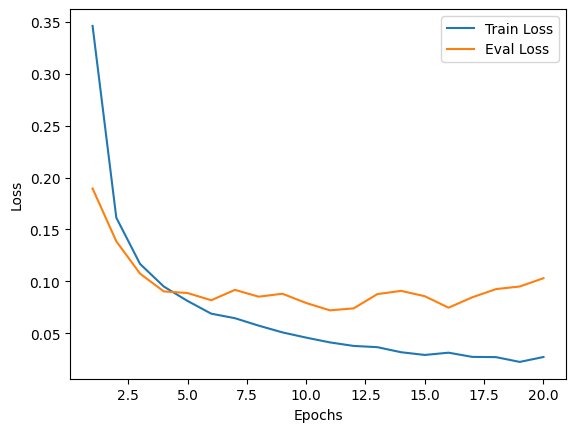

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, n_epoch + 1), train_losses, label='Train Loss')
plt.plot(range(1, n_epoch + 1), test_losses, label='Eval Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()